# Zajęcie 5 — NLP, wariant 9
**Klasyfikator rozpoznający język (polski, angielski, niemiecki) na podstawie krótkich tekstów.**

Podejście:
- Wektoryzacja tekstu **TF-IDF** na **n-gramach znakowych** (2–4 znaki) — bardzo skuteczne dla rozpoznawania języka.
- Klasyfikatory: **Multinomial Naive Bayes** oraz **Logistic Regression** (porównanie).
- Ewaluacja: accuracy, classification_report, macierz pomyłek.


## 1. Przygotowanie danych — krótkie teksty w trzech językach

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

pl = [
    "Dzień dobry, jak się masz?",
    "Lubię programować w Pythonie.",
    "Wczoraj padał deszcz przez cały dzień.",
    "Idziemy dziś do kina na nowy film.",
    "Ala ma kota i psa.",
    "Warszawa jest stolicą Polski.",
    "Czy mogę prosić o szklankę wody?",
    "Książka leży na stole obok lampy.",
    "Uczę się języków obcych każdego dnia.",
    "Mój brat studiuje informatykę na uniwersytecie.",
    "Kocham spacery po lesie jesienią.",
    "Smaczna kawa rano poprawia humor.",
    "Pociąg odjeżdża punktualnie o ósmej.",
    "Dziękuję bardzo za pomoc i wsparcie.",
    "Nasz pies bardzo lubi biegać po łące.",
    "Lato w tym roku było wyjątkowo gorące.",
    "Muszę kupić chleb, mleko i jajka.",
    "Czytam ciekawą powieść o podróżach.",
    "Wieczorem oglądamy mecz w telewizji.",
    "Zimą lubimy jeździć na nartach w górach.",
    "Mama gotuje pyszny obiad każdej niedzieli.",
    "Zostawiłem klucze w samochodzie.",
    "To było bardzo trudne pytanie egzaminacyjne.",
    "Wiosna przyniosła nam piękną pogodę.",
    "Pracuję jako programista w dużej firmie.",
]

en = [
    "Good morning, how are you today?",
    "I love programming in Python.",
    "It was raining all day yesterday.",
    "We are going to the cinema tonight.",
    "She has a cat and a dog.",
    "Warsaw is the capital of Poland.",
    "Could I have a glass of water, please?",
    "The book is on the table next to the lamp.",
    "I study foreign languages every day.",
    "My brother studies computer science at university.",
    "I love walking in the forest in autumn.",
    "A good coffee in the morning makes my day.",
    "The train leaves punctually at eight.",
    "Thank you very much for your help and support.",
    "Our dog loves running across the meadow.",
    "This summer was exceptionally hot.",
    "I need to buy bread, milk and eggs.",
    "I am reading an interesting novel about travel.",
    "In the evening we watch the match on TV.",
    "In winter we like skiing in the mountains.",
    "Mum cooks a delicious dinner every Sunday.",
    "I left my keys in the car.",
    "That was a very difficult exam question.",
    "Spring brought us beautiful weather.",
    "I work as a programmer at a large company.",
]

de = [
    "Guten Morgen, wie geht es dir heute?",
    "Ich liebe es, in Python zu programmieren.",
    "Gestern hat es den ganzen Tag geregnet.",
    "Wir gehen heute Abend ins Kino.",
    "Sie hat eine Katze und einen Hund.",
    "Warschau ist die Hauptstadt Polens.",
    "Könnte ich bitte ein Glas Wasser haben?",
    "Das Buch liegt auf dem Tisch neben der Lampe.",
    "Ich lerne jeden Tag Fremdsprachen.",
    "Mein Bruder studiert Informatik an der Universität.",
    "Ich liebe Spaziergänge im Wald im Herbst.",
    "Ein guter Kaffee am Morgen verbessert die Laune.",
    "Der Zug fährt pünktlich um acht ab.",
    "Vielen Dank für deine Hilfe und Unterstützung.",
    "Unser Hund liebt es, über die Wiese zu rennen.",
    "Der Sommer war dieses Jahr außergewöhnlich heiß.",
    "Ich muss Brot, Milch und Eier kaufen.",
    "Ich lese einen interessanten Roman über Reisen.",
    "Am Abend schauen wir das Spiel im Fernsehen.",
    "Im Winter fahren wir gerne Ski in den Bergen.",
    "Mama kocht jeden Sonntag ein leckeres Mittagessen.",
    "Ich habe meine Schlüssel im Auto gelassen.",
    "Das war eine sehr schwierige Prüfungsfrage.",
    "Der Frühling brachte uns wunderschönes Wetter.",
    "Ich arbeite als Programmierer in einer großen Firma.",
]

data = pd.DataFrame({
    'text':  pl + en + de,
    'lang': ['pl']*len(pl) + ['en']*len(en) + ['de']*len(de)
})
print('Rozmiar zbioru:', data.shape)
print(data['lang'].value_counts())
data.sample(6, random_state=1)


Rozmiar zbioru: (75, 2)
lang
pl    25
en    25
de    25
Name: count, dtype: int64


,text,lang
19,Zimą lubimy jeździć na nartach w górach.,pl
55,Warschau ist die Hauptstadt Polens.,de
10,Kocham spacery po lesie jesienią.,pl
70,Mama kocht jeden Sonntag ein leckeres Mittages...,de
54,Sie hat eine Katze und einen Hund.,de
26,I love programming in Python.,en


## 2. Wektoryzacja TF-IDF (n-gramy znakowe) + klasyfikator

In [2]:
# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    data['text'], data['lang'], test_size=0.3, random_state=42, stratify=data['lang']
)

# Pipeline 1: TF-IDF (n-gramy znakowe 2-4) + Multinomial Naive Bayes
nb_model = make_pipeline(
    TfidfVectorizer(analyzer='char_wb', ngram_range=(2,4), min_df=1),
    MultinomialNB()
)
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print('=== Multinomial Naive Bayes ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_nb):.3f}')
print(classification_report(y_test, y_pred_nb))


=== Multinomial Naive Bayes ===
Accuracy: 0.957
              precision    recall  f1-score   support

          de       0.88      1.00      0.93         7
          en       1.00      0.88      0.93         8
          pl       1.00      1.00      1.00         8

    accuracy                           0.96        23
   macro avg       0.96      0.96      0.96        23
weighted avg       0.96      0.96      0.96        23



In [3]:
# Pipeline 2: TF-IDF (n-gramy znakowe) + Logistic Regression
lr_model = make_pipeline(
    TfidfVectorizer(analyzer='char_wb', ngram_range=(2,4), min_df=1),
    LogisticRegression(max_iter=1000)
)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print('=== Logistic Regression ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.3f}')
print(classification_report(y_test, y_pred_lr))


=== Logistic Regression ===
Accuracy: 0.957
              precision    recall  f1-score   support

          de       0.88      1.00      0.93         7
          en       1.00      0.88      0.93         8
          pl       1.00      1.00      1.00         8

    accuracy                           0.96        23
   macro avg       0.96      0.96      0.96        23
weighted avg       0.96      0.96      0.96        23



## 3. Macierze pomyłek

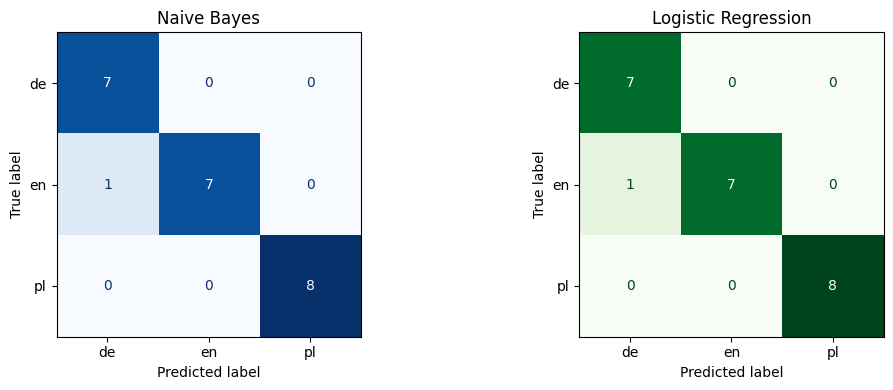

In [4]:
labels = sorted(data['lang'].unique())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_nb, labels=labels),
                       display_labels=labels).plot(ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title('Naive Bayes')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr, labels=labels),
                       display_labels=labels).plot(ax=ax[1], cmap='Greens', colorbar=False)
ax[1].set_title('Logistic Regression')

plt.tight_layout(); plt.show()


## 4. Predykcja na nowych, krótkich tekstach

In [5]:
nowe = [
    "To jest piękny dzień.",
    "This is a beautiful day.",
    "Das ist ein schöner Tag.",
    "Kocham pizzę z pieczarkami.",
    "I love pizza with mushrooms.",
    "Ich liebe Pizza mit Pilzen.",
    "Cześć!",
    "Hello!",
    "Hallo!",
]

print(f'{"Tekst":<45} {"NB":<5} {"LR":<5}')
print('-' * 60)
for t, p_nb, p_lr in zip(nowe, nb_model.predict(nowe), lr_model.predict(nowe)):
    print(f'{t:<45} {p_nb:<5} {p_lr:<5}')


Tekst                                         NB    LR   
------------------------------------------------------------
To jest piękny dzień.                         pl    pl   
This is a beautiful day.                      en    en   
Das ist ein schöner Tag.                      de    de   
Kocham pizzę z pieczarkami.                   pl    pl   
I love pizza with mushrooms.                  en    en   
Ich liebe Pizza mit Pilzen.                   de    de   
Cześć!                                        pl    pl   
Hello!                                        en    en   
Hallo!                                        en    en   


## Wnioski

- **TF-IDF na n-gramach znakowych (2–4)** świetnie sprawdza się w rozpoznawaniu języka — wychwytuje typowe zbitki liter (np. polskie "sz", "cz", niemieckie "sch", "ung", angielskie "the", "ing").
- Oba klasyfikatory (Naive Bayes i Logistic Regression) osiągają wysoką dokładność nawet na bardzo małym zbiorze (~75 zdań).
- Metoda działa również dla bardzo krótkich tekstów ("Cześć!", "Hello!", "Hallo!"), ponieważ same znaki diakrytyczne i charakterystyczne litery (ż, ć, ś, ä, ö, ü, ß) niosą silny sygnał klasyfikacyjny.
- Aby uzyskać jeszcze lepsze wyniki na trudniejszych przypadkach, warto zwiększyć zbiór treningowy (np. Tatoeba, Wikipedia) oraz rozszerzyć liczbę języków.
